In [11]:
import pandas as pd 

In [12]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
df.shape

(541909, 8)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# CustomerID cleaning

df = df.dropna(subset=["CustomerID"])

In [17]:
# Extracting returns data

df = df[df["Quantity"] > 0]

In [18]:
# Add Revenue

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [19]:
df.shape 

(397924, 9)

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
# Best selling products

df["Description"].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1724
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1397
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
Name: count, dtype: int64

In [23]:
# Top revenue-generating products

df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

In [25]:
# Country based sales 

df["Country"].value_counts().head(10)

Country
United Kingdom    354345
Germany             9042
France              8342
EIRE                7238
Spain               2485
Netherlands         2363
Belgium             2031
Switzerland         1842
Portugal            1462
Australia           1185
Name: count, dtype: int64

In [28]:
# Time analysis

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M")


df.groupby("Month")["Revenue"].sum()

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64

In [ ]:
# RFM (R = Recency / F = Frequency / M = Monetary)

# If the R,F and M values are high, the customer is a VIP; #
# otherwise, it is a lost customer.


In [38]:
# Customer Segmentation Foundation (RFM Analysis)

# RFM Table / Customer-Level Table 

rfm_df = df.copy()

In [32]:
# For reference date 

import datetime as dt

reference_date = rfm_df["InvoiceDate"].max() + dt.timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [34]:
# RFM

rfm = rfm_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "count",
    "Revenue": "sum"
})

In [35]:
# Columns name 

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [36]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,91.708689,2053.793018
std,100.009747,228.792852,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,17.000000,307.245000
50%,51.000000,41.000000,674.450000
75%,142.000000,100.000000,1661.640000
max,374.000000,7847.000000,280206.020000


In [39]:
##

# RFM Scores

rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"], 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])


In [40]:
# Creating a single score

rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,182,4310.00,5,5,5,555
12348.0,75,31,1797.24,2,3,4,234
12349.0,19,73,1757.55,4,4,4,444
12350.0,310,17,334.40,1,2,2,122


In [41]:
# Customer Segment

def segment(row):
    if row["RFM_Score"] == "555":
        return "VIP"
    elif row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Loyal"
    elif row["R_score"] <=2:
        return "Lost"
    else:
        return "Regular"

rfm["Segment"] = rfm.apply(segment, axis=1) 


In [43]:
rfm["Segment"].value_counts()

Segment
Lost       1708
Regular    1530
Loyal       795
VIP         306
Name: count, dtype: int64

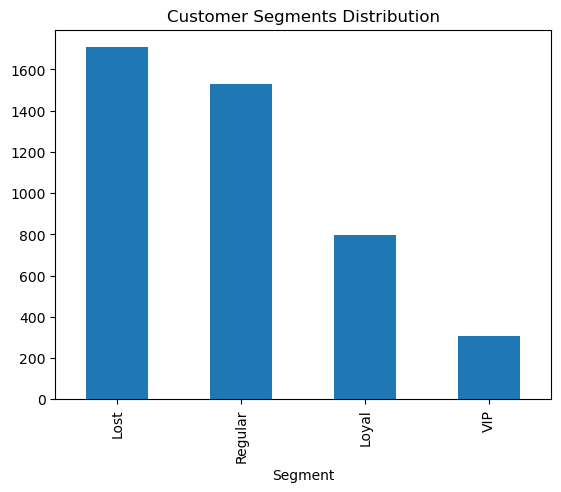

In [44]:
# Segment Visualization

import matplotlib.pyplot as plt 

rfm["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments Distribution")
plt.show()

In [45]:
# VIP Customers

rfm[rfm["Segment"] == "VIP"].head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12347.0,2,182,4310.00,5,5,5,555,VIP
12362.0,3,266,5226.23,5,5,5,555,VIP
12417.0,3,192,3649.10,5,5,5,555,VIP
12433.0,1,420,13375.87,5,5,5,555,VIP
12437.0,2,200,4951.41,5,5,5,555,VIP


In [46]:
# Most Valuable Customers

rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
14646.0,2,2080,280206.02,5,5,5,555,VIP
18102.0,1,431,259657.30,5,5,5,555,VIP
17450.0,8,337,194550.79,5,5,5,555,VIP
16446.0,1,3,168472.50,5,1,5,515,Regular
14911.0,1,5677,143825.06,5,5,5,555,VIP
12415.0,24,716,124914.53,4,5,5,455,Loyal
14156.0,10,1400,117379.63,5,5,5,555,VIP
17511.0,3,963,91062.38,5,5,5,555,VIP
16029.0,39,242,81024.84,3,5,5,355,Regular
